# **Project: Industrial IoT Anomaly Detection & Failure Diagnosis**

**Introduction:**

The main aim of the project is to design a smart monitoring system for a manufacturing process using IoT sensor data. The idea is to detect anomalies in the process in real-time and determine the nature of the failure occurring in the process. With the implementation of the proposed system, industries can move from **reactive maintenance** to predictive maintenance, which helps in saving costs on the process.

## **Importing Libraries**

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


### **Data Ingestion & Initial Exploration**

In [132]:
df = pd.read_csv('/content/drive/MyDrive/Anomaly_Detection_Project/Data/smart_manufacturing_data.csv')

## **Timestamp formate organised**

In [133]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Data successfully loaded! Total records:", len(df))
df.head()

Data successfully loaded! Total records: 100000


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


## **Feature engineering**
Creating rolling averages for temperature and vibration to capture sensor trends over time

In [134]:
# average of last 5 records
df['temp_rolling_avg'] = df.groupby('machine_id')['temperature'].transform(lambda x: x.rolling(window=5).mean())
df['vib_rolling_avg'] = df.groupby('machine_id')['vibration'].transform(lambda x: x.rolling(window=5).mean())

df = df.dropna()
print("New rolling average features added.")

New rolling average features added.


## **Correlation Heatmap**

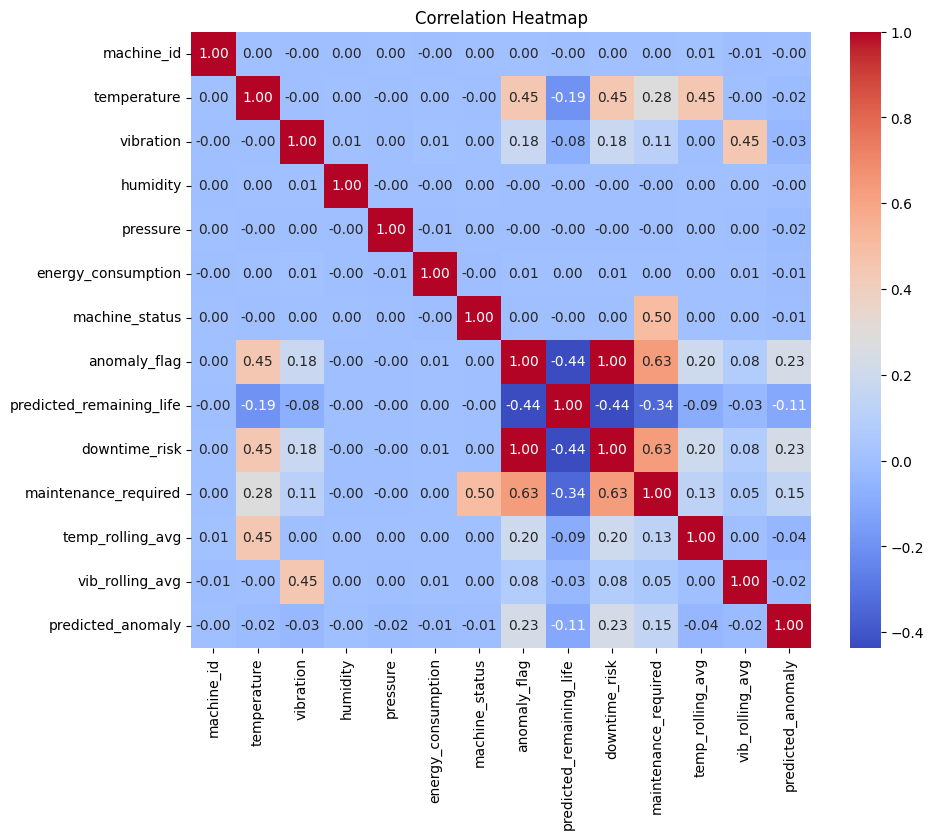

In [160]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig("/content/drive/MyDrive/Anomaly_Detection_Project/Reports/correlation_heatmap.png")

plt.show()

## **Temparature vs Anomaly relation figure**

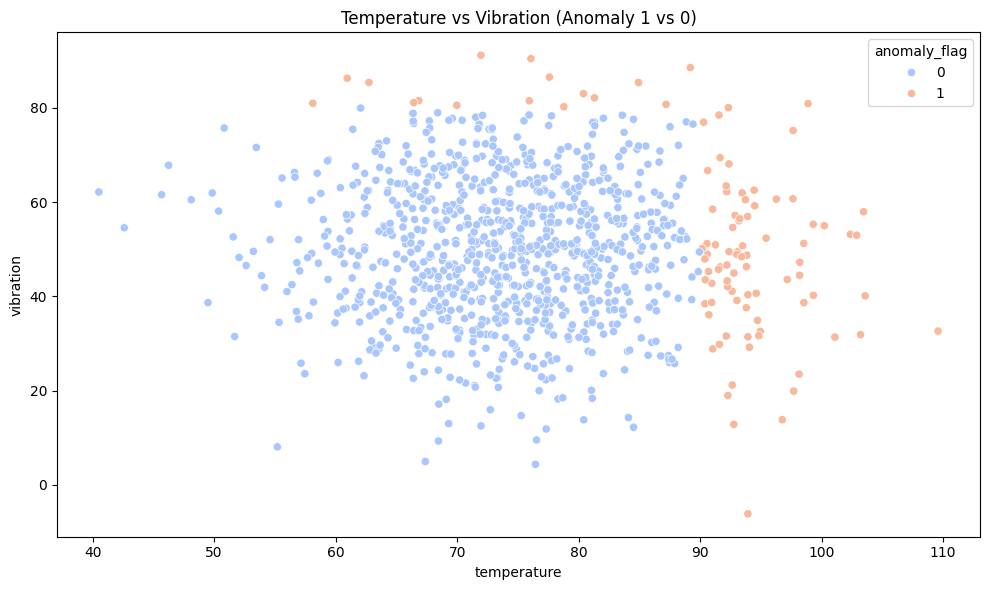

In [164]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(1000), x='temperature', y='vibration', hue='anomaly_flag', palette='coolwarm')
plt.title('Temperature vs Vibration (Anomaly 1 vs 0)')
plt.savefig("/content/drive/MyDrive/Anomaly_Detection_Project/Reports/temp_anomaly_relation.png")
plt.tight_layout()
plt.show()

## **Failure type count figure**

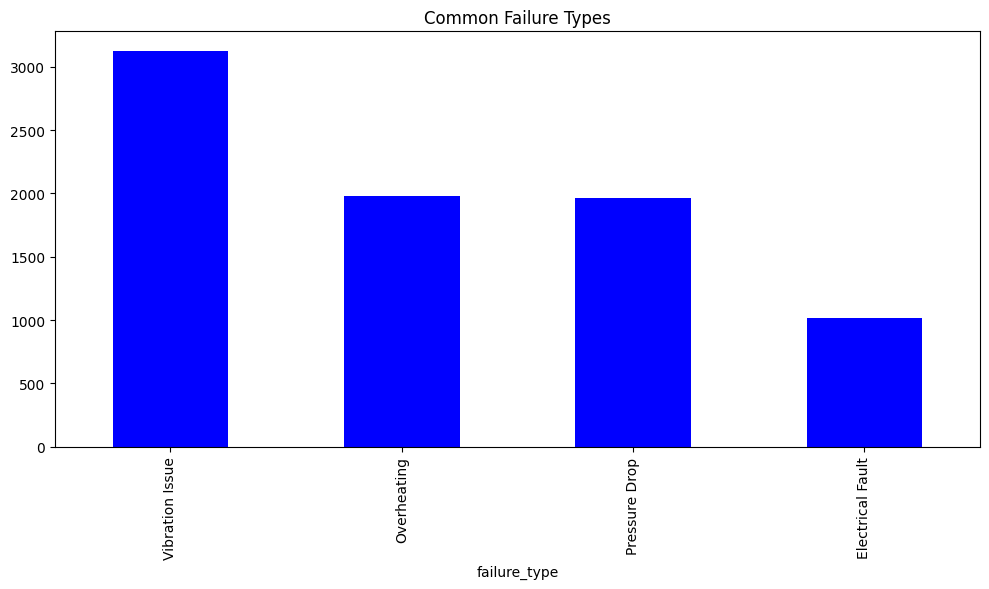

In [166]:
plt.figure(figsize=(10, 6))
df[df['failure_type'] != 'Normal']['failure_type'].value_counts().plot(kind='bar', color='blue')
plt.title('Common Failure Types')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Anomaly_Detection_Project/Reports/fail_type_count.png")
plt.tight_layout()
plt.show()


## **Anomaly detection**
Unsupervised Anomaly Detection using Isolation Forest

In [138]:
X = df[['temperature', 'vibration', 'pressure', 'energy_consumption', 'temp_rolling_avg', 'vib_rolling_avg']]
y = df['anomaly_flag']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest Model
iso_forest = IsolationForest(n_estimators=100, contamination=0.09, random_state=42)
iso_forest.fit(X_scaled)

# Prediction
df['predicted_anomaly'] = iso_forest.predict(X_scaled)
df['predicted_anomaly'] = df['predicted_anomaly'].map({1: 0, -1: 1}) # Convert to 0 and 1

print("Anomaly Detection model training complete.")

Anomaly Detection model training complete.


## **Failure Diagnosis**
Failure Type Diagnosis using Random Forest Classifier

In [148]:
# supervised learnign
anomaly_data = df[df['anomaly_flag'] == 1]
X_fail = anomaly_data[['temperature', 'vibration', 'pressure', 'energy_consumption']]
y_fail = anomaly_data['failure_type']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fail, y_fail, test_size=0.2, random_state=42)

# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_clf.fit(X_train_f, y_train_f)

print("Failure Type Classification model training complete.")

Failure Type Classification model training complete.


## **Feature Importance Chart**

/tmp/ipykernel_510/3419617205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=diagnosis_features, palette='viridis')


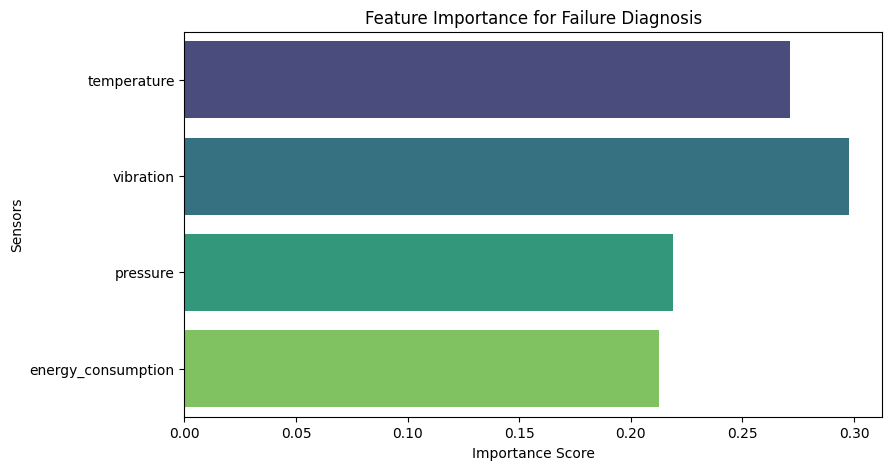

In [159]:
diagnosis_features = ['temperature', 'vibration', 'pressure', 'energy_consumption']
importances = rf_clf.feature_importances_

plt.figure(figsize=(9, 5))
sns.barplot(x=importances, y=diagnosis_features, palette='viridis')
plt.title('Feature Importance for Failure Diagnosis')
plt.xlabel('Importance Score')
plt.ylabel('Sensors')
plt.savefig("/content/drive/MyDrive/Anomaly_Detection_Project/Reports/feature_importance_chart.png")
plt.show()

## **Life prediction**

In [146]:
rf_reg = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf_reg.fit(X, df['predicted_remaining_life'])

RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42)

## **Performance evaluation**

In [142]:
print("\n--- 1. Anomaly Detection Report---")
print(classification_report(df['anomaly_flag'], df['predicted_anomaly']))

print("\n--- 2. Failure Diagnousis Report ---")
y_pred_diag = clf.predict(X_test)
print(classification_report(y_test, y_pred_diag))



--- 1. Anomaly Detection Report---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     90908
           1       0.30      0.30      0.30      8892

    accuracy                           0.87     99800
   macro avg       0.62      0.62      0.62     99800
weighted avg       0.88      0.87      0.88     99800


--- 2. Failure Diagnousis Report ---
                  precision    recall  f1-score   support

Electrical Fault       0.00      0.00      0.00        27
          Normal       0.92      1.00      0.96      1630
     Overheating       0.00      0.00      0.00        30
   Pressure Drop       0.00      0.00      0.00        34
 Vibration Issue       0.00      0.00      0.00        58

        accuracy                           0.92      1779
       macro avg       0.18      0.20      0.19      1779
    weighted avg       0.84      0.92      0.88      1779



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Predictive maintainance alert function**

In [143]:
def maintenance_alert_system(row_index):

    if row_index >= len(df):
        print(f"Error: Index {row_index} out of range. Max index is {len(df)-1}")
        return

    sample = df.iloc[[row_index]]
    input_data = sample[features]
    input_scaled = scaler.transform(input_data)

    is_anomaly = iso_forest.predict(input_scaled)[0]
    predicted_life = rf_reg.predict(input_data)[0]

    print("\n" + "="*45)
    print(f"MACHINE HEALTH REPORT (ID: {int(sample['machine_id'].values[0])})")
    print("="*45)
    print(f"Predicted Remaining Life: {predicted_life:.1f} Hours")

    if is_anomaly == -1:
        failure_type = rf_clf.predict(input_data)[0]
        print(f"STATUS: CRITICAL - Anomaly Detected!")
        print(f"CAUSE: {failure_type}")
    else:
        if predicted_life < 50:
            print("STATUS: 🟡 WARNING - Low Maintenance Life")
        else:
            print("STATUS: 🟢 HEALTHY - Normal Operating Condition")
    print("="*45)

## **Model saved**

In [149]:
import joblib

joblib.dump(iso_forest, '/content/drive/MyDrive/Anomaly_Detection_Project/Models/anomaly_model.pkl')
joblib.dump(rf_clf, '/content/drive/MyDrive/Anomaly_Detection_Project/Models/failure_classifier.pkl')
joblib.dump(rf_reg, '/content/drive/MyDrive/Anomaly_Detection_Project/Models/life_predictor.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Anomaly_Detection_Project/Models/scaler.pkl')

print("Models saved successfully!")

Models saved successfully!


# **Conclusion & Future Work**
---
### **Summary**
This project is successfully demonstrated as a **Industrial IoT Monitoring System**. Here, **Isolation Forest** is utilized to identify anomalies in sensor data, while **Random Forest Classifier** is utilized to diagnose failures such as **Overheating**, **Vibration issues**, etc. This hybrid approach allows us to shift gears seamlessly from **Traditional Reactive Maintenance** to **Data-Driven Predictive Maintenance**.

### **Future Scope**
1. **Deep Learning Integration:** Integration of **LSTM (Long Short-Term Memory)** networks to enhance the forecasting process of complex time-series data.
2. **Cloud & Edge Deployment:** Deployment of the model as a Cloud-based API or optimization of the model for **Edge Computing** devices to enable real-time diagnostics.
3. **Sensor Expansion:** Incorporation of additional diverse sensor inputs to enhance system reliability, such as acoustic or oil sensors.